# Wheel motion trace — D / T / TURN on the bench

Drive the robot through a **D** (distance), a **T** (timed), and a **TURN**
(in-place rotate) while streaming telemetry back over the USB serial link,
then chart each wheel's **position, speed, and acceleration** against time.

**Robot is on the stand, wheels off the ground** — safe to spin freely
(`.claude/rules/hardware-bench-testing.md`).

## How it works

Python owns the loop here: we `STREAM` telemetry at 20 ms, fire one motion
command, and drain the `TLM` frames + the `EVT done` line as they come back
on the same link — the "back channel". Each `TLM` frame carries, per wheel:

| chart quantity | telemetry source | unit |
|---|---|---|
| **position** | `enc=(left,right)` — signed cumulative encoder travel | mm |
| **speed (measured)** | `vel=(vL,vR)` — measured wheel velocity (signed) | mm/s |
| **speed (commanded)** | `cmd=(vL,vR)` — the velocity PID's own setpoint | mm/s |
| **tracking error** | *derived* — `cmd − vel` (what the PID is failing to track) | mm/s |
| **acceleration** | *derived* — `d(vel)/dt` over the firmware `t` timestamps | mm/s² |

The **commanded** trace (`cmd=`) is the velocity loop's setpoint — the number
the PID is chasing. Overlaid on the measured speed it shows exactly where the
loop overshoots or lags; the **error** panel plots the gap directly. `cmd=` is
emitted by both the real robot and the simulator (same firmware TLM path), so
the same notebook charts real and sim identically.

Acceleration is not telemetered, so we differentiate the velocity trace. A
light rolling-mean is applied to the (integer-quantized) velocity first, or
the derivative is dominated by quantization noise.

Speed is **signed on purpose**: the terminal reverse-creep this bench run is
meant to expose (sprint 092's open D/T decision — see
`clasi/issues/d-t-turn-terminal-reverse-stakeholder-decision.md`) shows up as
`vel` crossing below zero *after* `EVT done`. The dashed line on each chart
marks the `EVT done` instant.

## Running it

1. Robot on the stand, powered, USB connected. Confirm the port below.
2. Run all cells top-to-bottom. The capture cell talks to the hardware once
   and caches each run to `out/*.csv`; re-running the plot cells reads the
   cache (no hardware needed). **Delete a CSV to re-capture that verb**, or
   set `FORCE_RECAPTURE = True`.
3. The capture cell always restores the boot watchdog and sends `STOP` /
   `DEV STOP` in a `finally` block — motors are never left running.

In [1]:
import pathlib
import sys
import time

import numpy as np
import pandas as pd

# --- Paths: anchored to the repo, never CWD-relative (the kernel's working
# dir varies with how the notebook is launched). Walk up until we find the
# repo marker, then make robot_radio importable and locate the cache dir.
_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    # Fallback for an odd launch dir: the notebook's own known location.
    REPO = pathlib.Path(
        "/Volumes/Proj/proj/RobotProjects/radio-robot-elite")
sys.path.insert(0, str(REPO / "host"))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

from robot_radio.io.serial_conn import SerialConnection            # noqa: E402
from robot_radio.robot.protocol import (NezhaProtocol,             # noqa: E402
                                        parse_response, parse_tlm)

# --- Session configuration -------------------------------------------------
PORT = "/dev/cu.usbmodem2121102"   # bench robot; check `ls /dev/cu.usbmodem*`
MODE = None                        # None=auto-detect; "direct" | "relay"
STREAM_PERIOD = 20                 # [ms] telemetry cadence during a run
RUN_WATCHDOG_WINDOW = 20000        # [ms] widened for the session (max 60000)
BOOT_WATCHDOG_WINDOW = 1000        # [ms] firmware default, restored on exit
VEL_SMOOTH_WINDOW = 5              # samples of rolling mean before d/dt
FORCE_RECAPTURE = True            # True re-drives the robot even if cached

# The three runs. Each command form is the one proven on the stand by
# tests/bench/bench_ruckig_motion_verify.py.
#   D <vL> <vR> <travel[mm]>  — stops on distance   (reason=dist)
#   T <vL> <vR> <time[ms]>    — stops on time        (reason=time)
#   TURN <heading[cdeg]>      — in-place, stops on heading (reason=heading)
RUNS = [
    {"label": "D",    "verb": "D",    "command": "D 200 200 500",
     "reanchor": False, "timeout": 8.0, "post_done": 2.5},
    {"label": "T",    "verb": "T",    "command": "T 200 200 1500",
     "reanchor": False, "timeout": 8.0, "post_done": 2.5},
    {"label": "TURN", "verb": "TURN", "command": "TURN 9000",
     "reanchor": True,  "timeout": 14.0, "post_done": 2.5},
]
GLITCH_STEP = 300   # [mm] drop frames whose encoder reads jump this far from
                    # the local median in one ~20ms frame -- a bad read / wedge
                    # glitch, not real motion (>15 m/s). Counted, never silent.
print(f"repo:  {REPO}")
print(f"cache: {OUT_DIR}")
print(f"port:  {PORT}  (mode={MODE})")

repo:  /Volumes/Proj/proj/RobotProjects/radio-robot-elite
cache: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/notebooks/out
port:  /dev/cu.usbmodem2121102  (mode=None)


In [2]:
# --- Capture helpers -------------------------------------------------------
# One motion command -> a DataFrame of per-wheel position/speed/acceleration
# vs time, plus the host-relative timestamp of the EVT done edge.

def _drain(conn, frames, evt, duration, verb):
    """Read TLM/EVT for `duration` ms, appending frames and watching for
    the goal's own `EVT done`. Returns the done firmware-time once seen."""
    done_t = None
    for line in conn.read_lines(duration=duration):
        r = parse_response(line)
        if r is None:
            continue
        if r.tag == "TLM":
            f = parse_tlm(line)
            if f is not None and f.enc is not None and f.vel is not None:
                frames.append(f)
        elif r.tag == "EVT" and r.tokens and r.tokens[0] == "done":
            if len(r.tokens) < 2 or r.tokens[1] == verb:
                if done_t is None and frames:
                    done_t = frames[-1].t   # firmware [ms] of the last frame
    return done_t


def capture_run(conn, proto, run):
    """Settle, zero, stream, fire the command, and drain through + past
    EVT done. Returns (DataFrame, done_t_ms_relative)."""
    verb, command = run["verb"], run["command"]
    proto.send("STOP", read_timeout=200)
    time.sleep(1.3)                 # let any prior coast/reverse fully settle
    if run["reanchor"]:
        proto.set_internal_pose(0, 0, 0)
    proto.zero_encoders()
    time.sleep(0.2)
    conn.read_pending_lines()       # drop stale queue
    proto.stream(STREAM_PERIOD)
    time.sleep(0.15)                # USB-CDC settle before the drive command

    frames, evt = [], []
    resp = proto.send(command, read_timeout=500)
    if not any("OK" in ln for ln in resp.get("responses", [])):
        print(f"  WARN [{run['label']}] no OK to {command!r}: {resp}")

    done_t = None
    deadline = time.monotonic() + run["timeout"]
    while time.monotonic() < deadline:
        d = _drain(conn, frames, evt, 150, verb)
        if d is not None and done_t is None:
            done_t = d
            done_wall = time.monotonic()
        if done_t is not None and (time.monotonic() - done_wall) >= run["post_done"]:
            break
    proto.stream(0)
    proto.send("STOP", read_timeout=200)
    return _frames_to_df(frames, done_t)


def _frames_to_df(frames, done_t):
    """TLMFrame list -> tidy DataFrame. Time is firmware `t` [ms] made
    relative to the first frame; acceleration is d(smoothed vel)/dt."""
    if not frames:
        return pd.DataFrame(), None
    t0 = frames[0].t
    rows = [{"t": (f.t - t0) / 1000.0,          # [s] relative
             "pos_l": f.enc[0], "pos_r": f.enc[1],       # [mm]
             "vel_l": f.vel[0], "vel_r": f.vel[1],       # [mm/s] measured, signed
             # cmd= (PID setpoint) -- NaN when the frame omitted it (idle)
             "cmd_l": (f.cmd_vel[0] if f.cmd_vel else float("nan")),   # [mm/s]
             "cmd_r": (f.cmd_vel[1] if f.cmd_vel else float("nan"))}   # [mm/s]
            for f in frames]
    df = pd.DataFrame(rows).drop_duplicates(subset="t").reset_index(drop=True)

    # Drop physically-impossible single-frame encoder jumps (bad reads / wedge
    # glitches) -- a position that leaps > GLITCH_STEP mm from its own local
    # median in one ~20ms frame is a bad read, not real motion. Counted and
    # reported, never a silent truncation.
    if len(df) > 4:
        mask = pd.Series(False, index=df.index)
        for side in ("l", "r"):
            med = df[f"pos_{side}"].rolling(5, center=True, min_periods=1).median()
            mask |= (df[f"pos_{side}"] - med).abs() > GLITCH_STEP
        n_drop = int(mask.sum())
        if n_drop:
            print(f"  dropped {n_drop} encoder-glitch frame(s) (>{GLITCH_STEP}mm/frame)")
            df = df[~mask].reset_index(drop=True)

    # Tracking error the velocity PID actually sees: setpoint - measured.
    df["err_l"] = df["cmd_l"] - df["vel_l"]   # [mm/s]
    df["err_r"] = df["cmd_r"] - df["vel_r"]   # [mm/s]

    # Derive acceleration per wheel: smooth the quantized velocity, then take
    # a gradient against the (non-uniform) time axis. np.gradient handles the
    # variable dt from dropped/late frames.
    w = max(1, VEL_SMOOTH_WINDOW)
    t_s = df["t"].to_numpy()
    for side in ("l", "r"):
        v = df[f"vel_{side}"].rolling(w, center=True, min_periods=1).mean()
        df[f"acc_{side}"] = np.gradient(v.to_numpy(), t_s) if len(df) > 2 else 0.0

    done_rel = (done_t - t0) / 1000.0 if done_t is not None else None
    return df, done_rel


def cached_or_capture(run):
    """Load out/<label>.csv if present (and not forcing), else drive the
    robot and cache. Returns (DataFrame, done_t) — done_t stored as CSV attr
    via a sidecar column so a re-load recovers the marker."""
    csv = OUT_DIR / f"wheel_trace_{run['label']}.csv"
    if csv.exists() and not FORCE_RECAPTURE:
        df = pd.read_csv(csv)
        done = df["done_t"].iloc[0] if "done_t" in df and df["done_t"].notna().any() else None
        print(f"  cached: {csv.name} ({len(df)} frames, done_t={done}) "
              f"-- delete to re-capture")
        return df, (float(done) if done is not None and not pd.isna(done) else None)
    raise RuntimeError("no cache and capture must run in the connected cell")

In [3]:
# --- Drive the robot (once) and cache each run ----------------------------
# Safe teardown guaranteed: STOP + DEV STOP + boot watchdog restored in the
# finally block, so a mid-run exception or Ctrl-C never leaves motors live.
captures = {}
need = [r for r in RUNS
        if FORCE_RECAPTURE or not (OUT_DIR / f"wheel_trace_{r['label']}.csv").exists()]

if not need:
    print("all runs cached -- skipping hardware. (FORCE_RECAPTURE=True to re-drive)")
    for r in RUNS:
        captures[r["label"]] = cached_or_capture(r)
else:
    conn = SerialConnection(port=PORT, mode=MODE)
    proto = None
    try:
        info = conn.connect()
        if "error" in info:
            raise RuntimeError(f"connect failed: {info['error']}")
        print(f"connected: mode={info.get('mode')}  {info.get('device', '')}")
        proto = NezhaProtocol(conn)
        print(f"ID {proto.get_id()}   VER {proto.get_ver()}")
        proto.send(f"DEV WD {RUN_WATCHDOG_WINDOW}", read_timeout=300)

        for r in RUNS:
            csv = OUT_DIR / f"wheel_trace_{r['label']}.csv"
            if csv.exists() and not FORCE_RECAPTURE:
                captures[r["label"]] = cached_or_capture(r)
                continue
            print(f"\n=== {r['label']}: {r['command']} ===")
            df, done = capture_run(conn, proto, r)
            if df.empty:
                print(f"  WARN no frames captured for {r['label']}")
                captures[r["label"]] = (df, done)
                continue
            df_save = df.copy()
            df_save["done_t"] = done            # sidecar the marker into the CSV
            df_save.to_csv(csv, index=False)
            captures[r["label"]] = (df, done)
            print(f"  {len(df)} frames, done_t={done}  ->  {csv.name}")
    finally:
        if proto is not None:
            for c in ("STOP", "DEV STOP", f"DEV WD {BOOT_WATCHDOG_WINDOW}"):
                try:
                    proto.send(c, read_timeout=300)
                except Exception as exc:     # noqa: BLE001
                    print(f"  WARN cleanup {c!r}: {exc}")
            print("\n[safety] STOP + DEV STOP + DEV WD restored.")
        if conn.is_open:
            conn.disconnect()
            print("serial closed")

connected: mode=direct  
ID None   VER None

=== D: D 200 200 500 ===
  283 frames, done_t=2.904  ->  wheel_trace_D.csv

=== T: T 200 200 1500 ===
  WARN [T] no OK to 'T 200 200 1500': {'sent': 'T 200 200 1500', 'mode': 'direct', 'responses': []}
  462 frames, done_t=None  ->  wheel_trace_T.csv

=== TURN: TURN 9000 ===
  712 frames, done_t=None  ->  wheel_trace_TURN.csv

[safety] STOP + DEV STOP + DEV WD restored.
serial closed


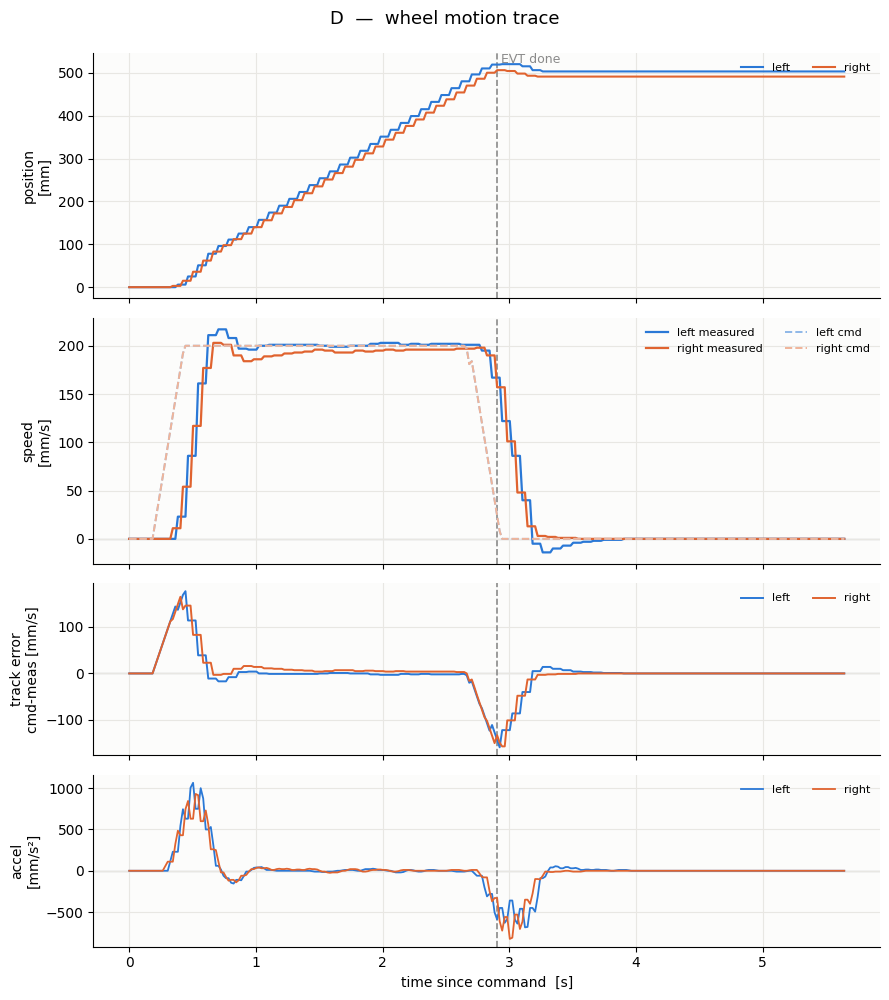

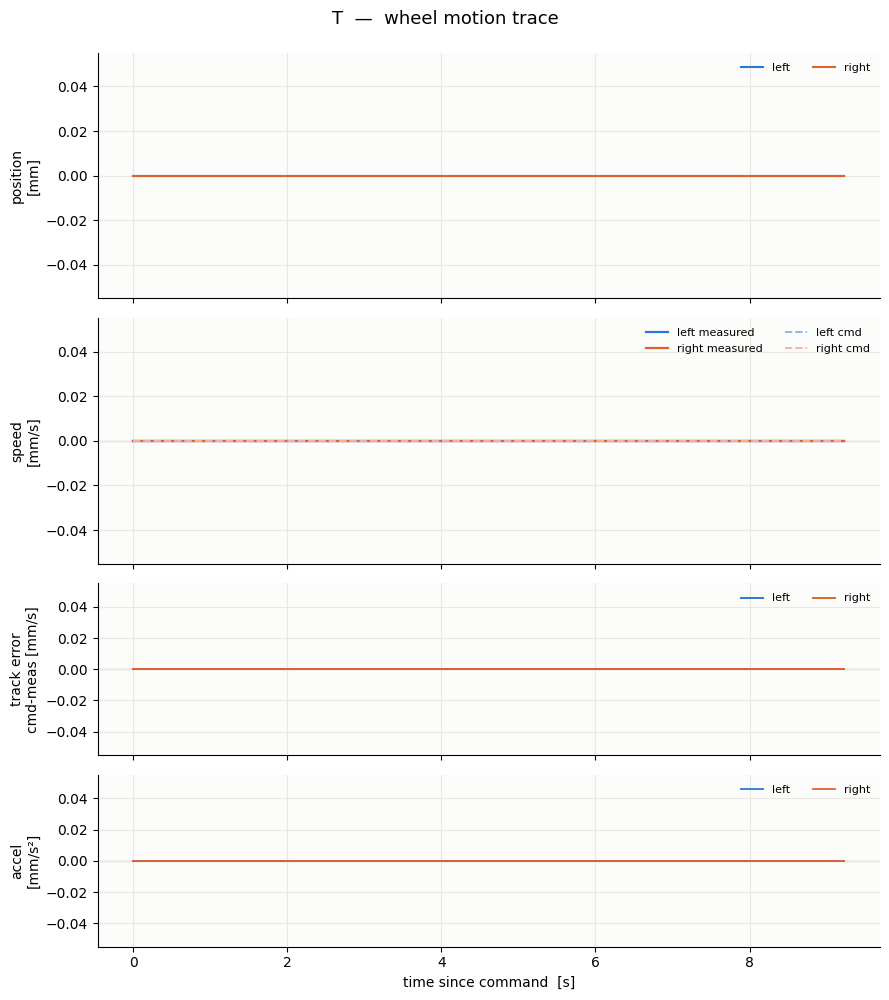

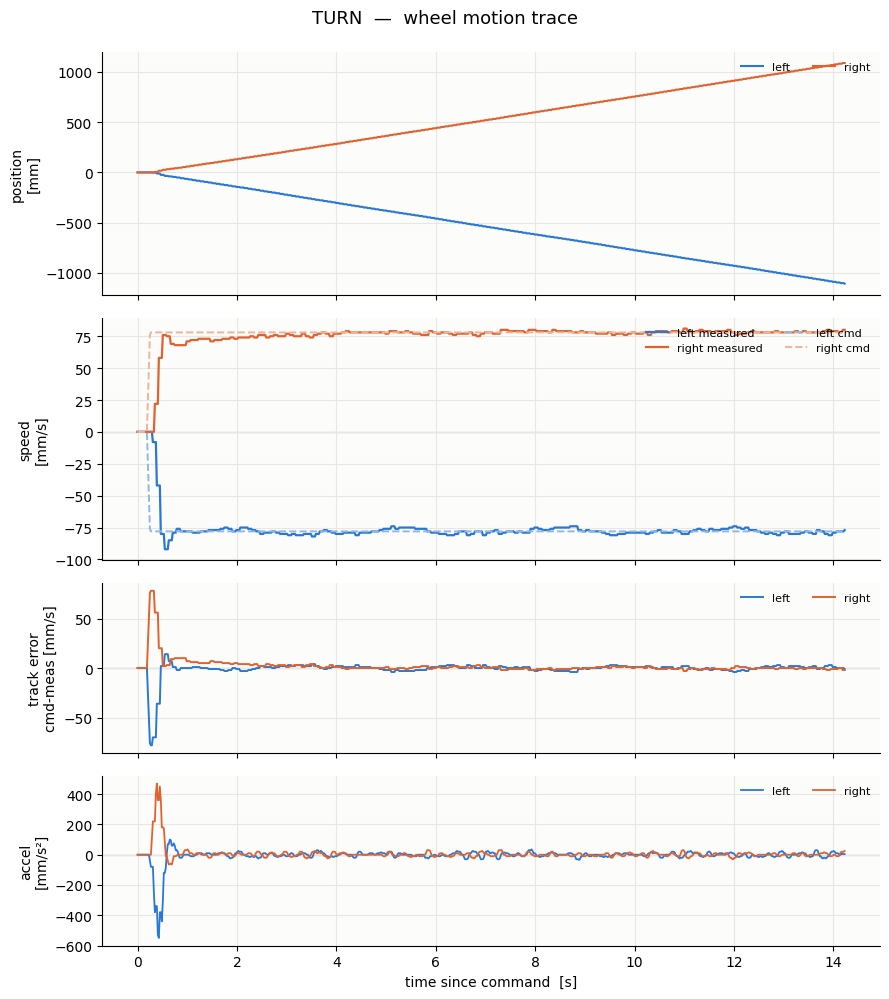

In [4]:
# --- Chart: position / speed(command vs measured) / error / acceleration ---
# One figure per verb. The SPEED panel overlays the PID's commanded setpoint
# (dashed) on the measured wheel speed (solid) -- their gap is what the loop
# is failing to track. The ERROR panel plots that gap (setpoint - measured)
# directly: a positive spike = the wheel lags the command; the terminal
# reverse-creep shows here as the measured speed crossing BELOW zero while
# the command sits at zero (error goes negative).
import matplotlib.pyplot as plt

LEFT = "#2a78d6"    # left wheel (measured)
RIGHT = "#e0632f"   # right wheel (measured)
CMD_L = "#8fb8e8"   # left commanded (lighter)
CMD_R = "#f0b499"   # right commanded (lighter)
DONE = "#8a8a8a"    # EVT done marker


def _has_cmd(df):
    return "cmd_l" in df.columns and df["cmd_l"].notna().any()


def plot_run(label, df, done_t):
    if df is None or df.empty:
        print(f"{label}: no data")
        return
    fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True,
                             facecolor="white",
                             gridspec_kw={"height_ratios": [2, 2, 1.4, 1.4]})
    fig.suptitle(f"{label}  —  wheel motion trace", fontsize=13, y=0.995)
    for ax in axes:
        ax.set_facecolor("#fcfcfb")
        ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        if done_t is not None:
            ax.axvline(done_t, color=DONE, ls="--", lw=1.2, zorder=2)

    ax_pos, ax_vel, ax_err, ax_acc = axes

    # 1. position
    ax_pos.plot(df["t"], df["pos_l"], color=LEFT, lw=1.5, label="left")
    ax_pos.plot(df["t"], df["pos_r"], color=RIGHT, lw=1.5, label="right")
    ax_pos.set_ylabel("position\n[mm]")

    # 2. speed: measured (solid) + commanded setpoint (dashed)
    ax_vel.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax_vel.plot(df["t"], df["vel_l"], color=LEFT, lw=1.6, label="left measured")
    ax_vel.plot(df["t"], df["vel_r"], color=RIGHT, lw=1.6, label="right measured")
    if _has_cmd(df):
        ax_vel.plot(df["t"], df["cmd_l"], color=CMD_L, lw=1.4, ls="--", label="left cmd")
        ax_vel.plot(df["t"], df["cmd_r"], color=CMD_R, lw=1.4, ls="--", label="right cmd")
    ax_vel.set_ylabel("speed\n[mm/s]")

    # 3. tracking error (cmd - measured)
    ax_err.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    if _has_cmd(df):
        ax_err.plot(df["t"], df["err_l"], color=LEFT, lw=1.4, label="left")
        ax_err.plot(df["t"], df["err_r"], color=RIGHT, lw=1.4, label="right")
    else:
        ax_err.text(0.5, 0.5, "no cmd= in this capture (older firmware)",
                    transform=ax_err.transAxes, ha="center", va="center",
                    color="#999", fontsize=9)
    ax_err.set_ylabel("track error\ncmd-meas [mm/s]")

    # 4. acceleration
    ax_acc.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax_acc.plot(df["t"], df["acc_l"], color=LEFT, lw=1.3, label="left")
    ax_acc.plot(df["t"], df["acc_r"], color=RIGHT, lw=1.3, label="right")
    ax_acc.set_ylabel("accel\n[mm/s²]")

    for ax in axes:
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
    if done_t is not None:
        ax_pos.text(done_t, ax_pos.get_ylim()[1], " EVT done",
                    color=DONE, fontsize=9, va="top")
    ax_acc.set_xlabel("time since command  [s]")
    fig.tight_layout()
    plt.show()


for r in RUNS:
    df, done = captures.get(r["label"], (None, None))
    plot_run(r["label"], df, done)

In [5]:
# --- Terminal-phase readout: reverse-creep after EVT done ------------------
# The number that drives the sprint-092 D/T decision: how far does each wheel
# travel BACKWARD (against its own established direction) after the goal
# reports done?  >~1 mm is real reverse-creep, not encoder noise.

def reverse_creep(df, done_t):
    if df is None or df.empty or done_t is None:
        return None
    post = df[df["t"] >= done_t]
    if post.empty:
        return None
    out = {}
    for side in ("l", "r"):
        pos = df[f"pos_{side}"]
        sign = 1.0 if pos.iloc[-1] - pos.iloc[0] >= 0 else -1.0
        at_done = pos[df["t"] <= done_t].iloc[-1] if (df["t"] <= done_t).any() else pos.iloc[0]
        worst_back = ((post[f"pos_{side}"] - at_done) * sign).min()
        out[side] = round(max(0.0, -worst_back), 2)   # [mm] backward travel
    return out

rows = []
for r in RUNS:
    df, done = captures.get(r["label"], (None, None))
    creep = reverse_creep(df, done)
    rows.append({"verb": r["label"], "command": r["command"],
                 "frames": 0 if df is None else len(df),
                 "reverse_left": None if creep is None else creep["l"],   # [mm]
                 "reverse_right": None if creep is None else creep["r"]})  # [mm]
pd.DataFrame(rows)

,verb,command,frames,reverse_left,reverse_right
0,D,D 200 200 500,283,16.0,15.0
1,T,T 200 200 1500,462,NaN,NaN
2,TURN,TURN 9000,712,NaN,NaN
